In [3]:
# GMM Clustering on Marketing Campaign Dataset
# This notebook uses the `dl_class` environment which already contains
# pandas, scikit-learn, matplotlib, numpy and other libraries.

import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# path to data
csv_path = r"c:\Users\LENOVO\Desktop\Sem2\Advanced Machine Learning Techniques\6\Data\marketing_campaign.csv"

# load and inspect
df = pd.read_csv(csv_path, sep=';')
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
# preprocessing and scaling

# drop identifiers and date
df_proc = df.drop(columns=[c for c in ['ID','Dt_Customer'] if c in df.columns])

# numeric features
num_cols = df_proc.select_dtypes(include=[np.number]).columns.tolist()
df_proc[num_cols] = df_proc[num_cols].fillna(df_proc[num_cols].mean())

# categorical columns
cat_cols = df_proc.select_dtypes(include=['object']).columns.tolist()
if cat_cols:
    # newer sklearn uses sparse_output instead of sparse
    from sklearn import __version__ as _skl_ver
    enc_kwargs = {'handle_unknown':'ignore'}
    if tuple(map(int, _skl_ver.split('.')[:2])) >= (1,2):
        enc_kwargs['sparse_output'] = False
    else:
        enc_kwargs['sparse'] = False
    enc = OneHotEncoder(**enc_kwargs)
    cat_mat = enc.fit_transform(df_proc[cat_cols])
    cat_df = pd.DataFrame(cat_mat, columns=enc.get_feature_names_out(cat_cols), index=df_proc.index)
    df_proc = pd.concat([df_proc.drop(columns=cat_cols), cat_df], axis=1)

# scale
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_proc), columns=df_proc.columns, index=df_proc.index)

df_scaled.head()


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,-0.985345,0.235327,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,...,-0.444816,-0.526385,-0.029894,-0.036621,-0.339909,-0.792406,1.914854,-0.591099,-0.188676,-0.029894
1,-1.235733,-0.235826,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,...,-0.444816,-0.526385,-0.029894,-0.036621,-0.339909,-0.792406,1.914854,-0.591099,-0.188676,-0.029894
2,-0.317643,0.773633,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,...,-0.444816,-0.526385,-0.029894,-0.036621,-0.339909,-0.792406,-0.522233,1.691765,-0.188676,-0.029894
3,1.268149,-1.022732,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,...,-0.444816,-0.526385,-0.029894,-0.036621,-0.339909,-0.792406,-0.522233,1.691765,-0.188676,-0.029894
4,1.017761,0.241519,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,...,-0.444816,1.899751,-0.029894,-0.036621,-0.339909,1.261980,-0.522233,-0.591099,-0.188676,-0.029894


In [6]:
# fit Gaussian Mixture Model and assign clusters

n_components = 4

gm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=0)
gm.fit(df_scaled)
labels = gm.predict(df_scaled)

# show cluster counts
pd.Series(labels).value_counts()


2    965
0    836
1    251
3    188
Name: count, dtype: int64

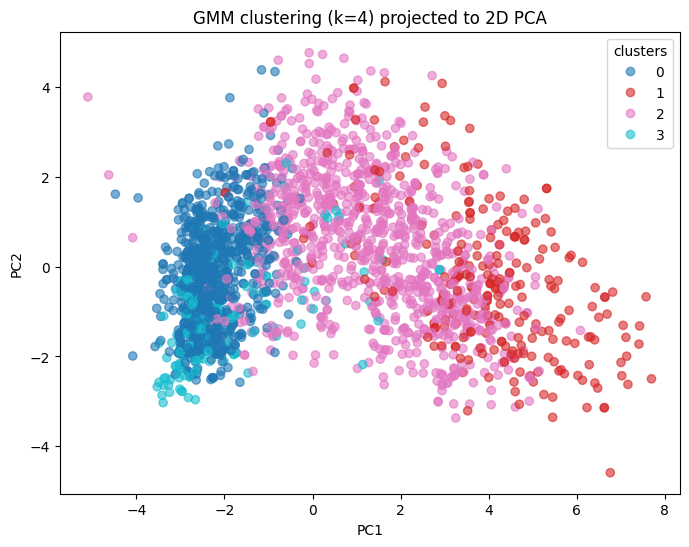

saved labeled dataset to marketing_campaign_with_clusters.csv


In [7]:
# visualize clusters in 2D using PCA

pca = PCA(n_components=2)
xy = pca.fit_transform(df_scaled)
plt.figure(figsize=(8,6))
scatter = plt.scatter(xy[:,0], xy[:,1], c=labels, cmap='tab10', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'GMM clustering (k={n_components}) projected to 2D PCA')
plt.legend(*scatter.legend_elements(), title="clusters")
plt.show()

# attach labels and save to csv
out_df = df_scaled.copy()
out_df['cluster'] = labels
out_df.to_csv('marketing_campaign_with_clusters.csv', index=False)
print('saved labeled dataset to marketing_campaign_with_clusters.csv')
